# Exploratory Data Analysis: Mufulira Master Capital Investment Framework

## 1. Introduction

This notebook performs exploratory data analysis, data-quality assessment, cleaning, preprocessing, visualization, and validation of the Mufulira Municipal Council Master Capital Investment Framework dataset.

The analysis aims to understand the structure of the council's planned capital investments and identify patterns across the available investment fields.

The objectives are to:

- inspect the structure and contents of the raw dataset;
- identify missing, duplicated, and inconsistent records;
- identify placeholder values such as `Unspecified`;
- apply appropriate cleaning and preprocessing techniques;
- explore the distribution of capital investment records;
- verify that the final cleaned dataset contains no null, NaN, or unresolved placeholder values; and
- export the cleaned dataset as a pipe-delimited CSV file.

The raw dataset is preserved separately and is not modified by this notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

input_path = (
    "../db-unza26-csc4792-mufulira_master_capital_investment_framework.csv"
)

output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792-mufulira_master_capital_investment_framework.csv"
)

df = pd.read_csv(
    input_path,
    sep="|"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (80, 10)


,Sector,Main_Objective,Specific_Objective_or_Program,Project_Description,Cost_ZMW,Proposed_Source_of_Funds,Location,Ward,Responsible_Agency,Implementation_Period
0,Water and Sanitation,Unspecified,To increase number of water points in peri urb...,Unspecified,150000000.00,Unspecified,Mufulira,All wards,"Water needs assessments, Aquifer exploration a...",2023-2032
1,Water and Sanitation,Unspecified,To increase water storage,Unspecified,50500.00,Unspecified,Mufulira,Kafue,"Dams’ assessments, plan and design",2023-2032
2,Water and Sanitation,Unspecified,To reduce vandalism of water points and network,Unspecified,50000.00,Unspecified,Mufulira,All peri urban wards in all the 3,Hold quarterly community sensitization meetings,2023-2032
3,Water and Sanitation,Unspecified,CLTS,MDGI,122545.50,Unspecified,Mufulira,"Kangwa Nsuluka, Luansobe & Bwananyina",Unspecified,2023-2032
4,Water and Sanitation,Unspecified,CLTS,MDGI,179124.00,Unspecified,Mufulira,"Kangwa Nsuluka, Luansobe & Bwananyina",Unspecified,2023-2032


## 2. Initial Dataset Inspection

The initial inspection examines the dimensions, column names, data types, missing values, duplicate records, and sample records in the raw Master Capital Investment Framework dataset.

This provides an overview of the dataset and identifies the data-quality issues that must be addressed during preprocessing.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 10 records:")
display(df.head(10))

Number of rows: 80
Number of columns: 10

Column names:
['Sector', 'Main_Objective', 'Specific_Objective_or_Program', 'Project_Description', 'Cost_ZMW', 'Proposed_Source_of_Funds', 'Location', 'Ward', 'Responsible_Agency', 'Implementation_Period']

Data types:
Sector                           str
Main_Objective                   str
Specific_Objective_or_Program    str
Project_Description              str
Cost_ZMW                         str
Proposed_Source_of_Funds         str
Location                         str
Ward                             str
Responsible_Agency               str
Implementation_Period            str
dtype: object

Missing values:


Sector                           0
Main_Objective                   0
Specific_Objective_or_Program    0
Project_Description              0
Cost_ZMW                         0
Proposed_Source_of_Funds         0
Location                         0
Ward                             0
Responsible_Agency               0
Implementation_Period            0
dtype: int64


Duplicate rows: 0

First 10 records:


,Sector,Main_Objective,Specific_Objective_or_Program,Project_Description,Cost_ZMW,Proposed_Source_of_Funds,Location,Ward,Responsible_Agency,Implementation_Period
0,Water and Sanitation,Unspecified,To increase number of water points in peri urb...,Unspecified,150000000.00,Unspecified,Mufulira,All wards,"Water needs assessments, Aquifer exploration a...",2023-2032
1,Water and Sanitation,Unspecified,To increase water storage,Unspecified,50500.00,Unspecified,Mufulira,Kafue,"Dams’ assessments, plan and design",2023-2032
2,Water and Sanitation,Unspecified,To reduce vandalism of water points and network,Unspecified,50000.00,Unspecified,Mufulira,All peri urban wards in all the 3,Hold quarterly community sensitization meetings,2023-2032
3,Water and Sanitation,Unspecified,CLTS,MDGI,122545.50,Unspecified,Mufulira,"Kangwa Nsuluka, Luansobe & Bwananyina",Unspecified,2023-2032
4,Water and Sanitation,Unspecified,CLTS,MDGI,179124.00,Unspecified,Mufulira,"Kangwa Nsuluka, Luansobe & Bwananyina",Unspecified,2023-2032
5,Water and Sanitation,Unspecified,CLTS,MDGI,142560.00,Unspecified,Mufulira,"Kangwa Nsuluka, Luansobe & Bwananyina",Unspecified,2023-2032
6,Water and Sanitation,Unspecified,CLTS,MDGI,384975.00,Unspecified,Mufulira,"Mutundu, Mainasoko, Bwafwano & Murundu",Unspecified,2023-2032
7,Water and Sanitation,Unspecified,Quality water monitoring from boreholes,RWSSP,198000.00,Unspecified,Mufulira,"Luansobe, Kangwa Nsuluka, Kalukanya, Kamuchang...",Unspecified,2023-2032
8,Water and Sanitation,Unspecified,Commemora tion of World Hand Washing Day,RWSSP,225000.00,Unspecified,Mufulira,Bwananyina,Unspecified,2023-2032
9,Water and Sanitation,Unspecified,Commemora tion of World Toilet Day,RWSSP,225000.00,Unspecified,Mufulira,Kangwa Nsuluka,Unspecified,2023-2032


## 3. Identification of Missing and Placeholder Values

Missing information in extracted datasets may appear as actual null values, blank strings, or textual placeholders such as `Unspecified`, `N/A`, or `None`.

These values are identified before cleaning so that they can be handled systematically according to the type and meaning of each field.

In [3]:
missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

print("Missing and placeholder values by column:\n")

for column in df.columns:
    values = df[column].astype("string").str.strip()

    null_count = int(df[column].isna().sum())
    placeholder_count = int(values.isin(missing_tokens).sum())

    if null_count > 0 or placeholder_count > 0:
        print(
            f"{column}: "
            f"{null_count} actual nulls, "
            f"{placeholder_count} placeholder values"
        )

Missing and placeholder values by column:

Main_Objective: 0 actual nulls, 80 placeholder values
Specific_Objective_or_Program: 0 actual nulls, 16 placeholder values
Project_Description: 0 actual nulls, 58 placeholder values
Cost_ZMW: 0 actual nulls, 7 placeholder values
Proposed_Source_of_Funds: 0 actual nulls, 16 placeholder values
Responsible_Agency: 0 actual nulls, 31 placeholder values


## 4. Creation of Cleaned Working Dataset

A separate working copy is created so that the original extracted dataset remains unchanged.

Textual representations of missing information are temporarily standardized as missing values. They will be resolved during the preprocessing stage and will not remain in the final cleaned dataset.

In [4]:
df_cleaned = df.copy()

for column in df_cleaned.columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype("string")
        .str.strip()
        .replace(missing_tokens, pd.NA)
    )

print("Cleaned working dataset created.")
display(df_cleaned.head())

Cleaned working dataset created.


,Sector,Main_Objective,Specific_Objective_or_Program,Project_Description,Cost_ZMW,Proposed_Source_of_Funds,Location,Ward,Responsible_Agency,Implementation_Period
0,Water and Sanitation,<NA>,To increase number of water points in peri urb...,<NA>,150000000.00,<NA>,Mufulira,All wards,"Water needs assessments, Aquifer exploration a...",2023-2032
1,Water and Sanitation,<NA>,To increase water storage,<NA>,50500.00,<NA>,Mufulira,Kafue,"Dams’ assessments, plan and design",2023-2032
2,Water and Sanitation,<NA>,To reduce vandalism of water points and network,<NA>,50000.00,<NA>,Mufulira,All peri urban wards in all the 3,Hold quarterly community sensitization meetings,2023-2032
3,Water and Sanitation,<NA>,CLTS,MDGI,122545.50,<NA>,Mufulira,"Kangwa Nsuluka, Luansobe & Bwananyina",<NA>,2023-2032
4,Water and Sanitation,<NA>,CLTS,MDGI,179124.00,<NA>,Mufulira,"Kangwa Nsuluka, Luansobe & Bwananyina",<NA>,2023-2032


## 5. Duplicate Record Handling

Duplicate records may cause the same capital investment entry to be counted more than once. Duplicate rows are therefore identified and removed from the cleaned working dataset.

In [5]:
duplicate_count = int(df_cleaned.duplicated().sum())

print("Duplicate rows identified:", duplicate_count)

df_cleaned = df_cleaned.drop_duplicates().copy()

print("Rows remaining after duplicate removal:", len(df_cleaned))

Duplicate rows identified: 0
Rows remaining after duplicate removal: 80


## 6. Data-Type Assessment

The cleaned dataset is divided into numerical and text or categorical fields.

This distinction is important because missing numerical values and missing descriptive or categorical values require different preprocessing approaches.

In [6]:
numeric_columns = df_cleaned.select_dtypes(
    include=["number"]
).columns.tolist()

text_columns = [
    column
    for column in df_cleaned.columns
    if column not in numeric_columns
]

print("Numerical columns:")
print(numeric_columns)

print("\nText/categorical columns:")
print(text_columns)

Numerical columns:
[]

Text/categorical columns:
['Sector', 'Main_Objective', 'Specific_Objective_or_Program', 'Project_Description', 'Cost_ZMW', 'Proposed_Source_of_Funds', 'Location', 'Ward', 'Responsible_Agency', 'Implementation_Period']


## 7. Missing-Value Treatment

Missing values are handled according to the type and purpose of each field.

For numerical variables, the median is used where a valid numerical distribution exists because it is less sensitive to extreme values.

For categorical and descriptive fields, the most frequent valid value is used where an appropriate repeated value exists. Where no valid repeated value exists, the explicit value `Not recorded` is used rather than leaving the field null.

These rules ensure that the final cleaned dataset contains complete values while avoiding unsupported numerical assumptions.

In [7]:
# Numerical fields: median imputation
for column in numeric_columns:
    if df_cleaned[column].isna().any():
        median_value = df_cleaned[column].median()

        if pd.notna(median_value):
            df_cleaned[column] = df_cleaned[column].fillna(median_value)

# Text/categorical fields
for column in text_columns:
    if df_cleaned[column].isna().any():
        mode_values = df_cleaned[column].mode(dropna=True)

        if len(mode_values) > 0:
            df_cleaned[column] = df_cleaned[column].fillna(
                mode_values.iloc[0]
            )
        else:
            df_cleaned[column] = df_cleaned[column].fillna(
                "Not recorded"
            )

print("Missing-value treatment completed.")

Missing-value treatment completed.


## 8. Missing-Value Verification

The cleaned working dataset is checked to determine whether any null or NaN values remain after preprocessing.

In [8]:
remaining_missing = int(df_cleaned.isna().sum().sum())

print("Total remaining null/NaN values:", remaining_missing)

display(df_cleaned.isna().sum())

Total remaining null/NaN values: 0


Sector                           0
Main_Objective                   0
Specific_Objective_or_Program    0
Project_Description              0
Cost_ZMW                         0
Proposed_Source_of_Funds         0
Location                         0
Ward                             0
Responsible_Agency               0
Implementation_Period            0
dtype: int64

## 9. Capital Investment Categories

The categorical fields are examined to identify the main dimensions represented in the Master Capital Investment Framework.

This helps determine which fields are most suitable for meaningful exploratory analysis and visualization.

In [9]:
categorical_summary = {}

for column in text_columns:
    counts = df_cleaned[column].value_counts(dropna=True)
    categorical_summary[column] = len(counts)

categorical_summary = (
    pd.Series(categorical_summary)
    .sort_values()
)

print("Number of unique values by categorical field:")
display(categorical_summary)

Number of unique values by categorical field:


Main_Objective                    1
Implementation_Period             1
Sector                           11
Project_Description              15
Ward                             25
Location                         27
Responsible_Agency               29
Proposed_Source_of_Funds         33
Cost_ZMW                         49
Specific_Objective_or_Program    58
dtype: int64

## 10. Capital Investment Distribution

A bar chart is used to compare the frequency of records across a suitable categorical field from the Master Capital Investment Framework.

The field with a manageable number of categories is selected to keep the visualization readable and meaningful.

Selected field: Sector


Sector
Education                                             20
Water and Sanitation                                  15
Public Health, Solid Waste Management & Sanitation    15
Agriculture, Livestock, Veterinary & Fisheries         8
Community Development, Gender & Social Welfare         8
Street Lighting, Market & Bus Station Lighting         4
Sports, Youth Recreation & Culture                     3
Forestry, Environment & Natural Resources              2
Public Infrastructure, Roads, Bridges & Culverts       2
Disaster Risk Reduction & Fire Services                2
Mining, Commerce, Trade & Industrial Development       1
Name: count, dtype: Int64

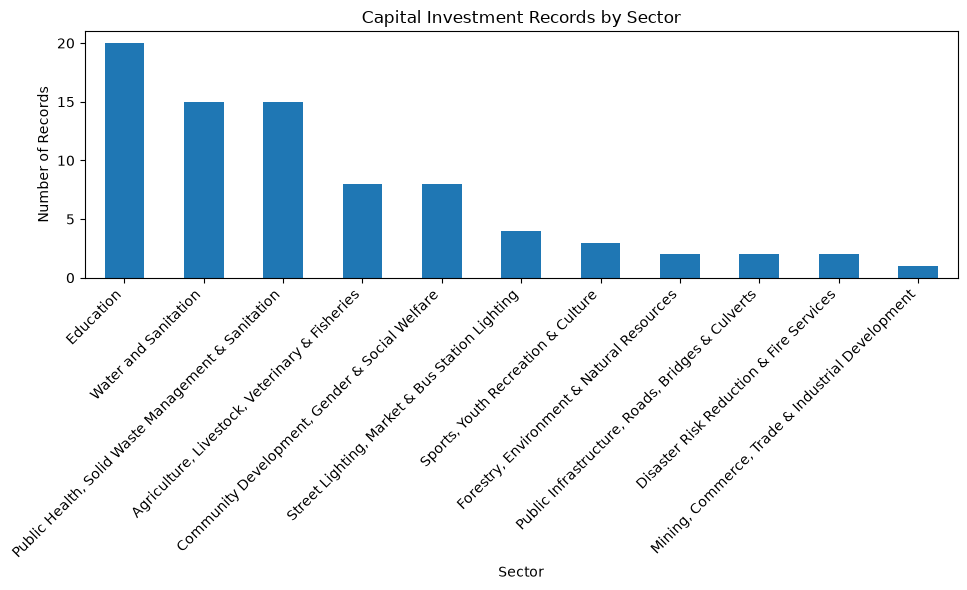

In [10]:
candidate_columns = []

for column in text_columns:
    counts = df_cleaned[column].value_counts(dropna=True)

    if 2 <= len(counts) <= 15:
        candidate_columns.append((column, counts))

if candidate_columns:
    selected_column, distribution = candidate_columns[0]

    print("Selected field:", selected_column)
    display(distribution)

    plt.figure(figsize=(10, 6))

    distribution.plot(kind="bar")

    plt.title(f"Capital Investment Records by {selected_column}")
    plt.xlabel(selected_column)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()
else:
    print("No categorical field with a suitable number of categories was found.")

## 11. Key Findings

The exploratory analysis of the Mufulira Municipal Council Master Capital Investment Framework provided an overview of the structure and distribution of capital investment records.

The analysis identified the main categorical characteristics represented in the framework and examined their frequency across the available records.

Data-quality assessment addressed duplicate records, missing values, and placeholder values while preserving the original extracted information as far as possible.

The cleaned dataset provides a more consistent basis for subsequent analysis of the council's planned capital investments.

## 12. Cleaning and Preprocessing Summary

The following preprocessing operations were applied to the dataset:

1. The raw dataset was loaded using the pipe (`|`) delimiter.
2. Missing and placeholder values were identified.
3. A separate working copy was created so that the raw dataset remained unchanged.
4. Duplicate records were identified and removed.
5. Numerical missing values were handled using the median where appropriate.
6. Categorical and descriptive missing values were handled using the most frequent valid value, or `Not recorded` where no suitable repeated value existed.
7. Text values were standardized by removing unnecessary leading and trailing whitespace.
8. The cleaned dataset was checked before export.

## 13. Final Data Quality Verification

The final cleaning stage ensures that the dataset contains no null values, NaN values, unresolved `Unspecified` values, or duplicate records before it is exported.

In [11]:
# Standardize text fields
for column in df_cleaned.columns:
    if (
        df_cleaned[column].dtype == "object"
        or str(df_cleaned[column].dtype) == "string"
    ):
        df_cleaned[column] = (
            df_cleaned[column]
            .astype("string")
            .str.strip()
        )

# Replace any remaining placeholder values
final_missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

for column in df_cleaned.columns:
    df_cleaned[column] = df_cleaned[column].replace(
        final_missing_tokens,
        pd.NA
    )

# Fill anything that still became missing
for column in df_cleaned.columns:
    if df_cleaned[column].isna().any():
        if column in numeric_columns:
            median_value = df_cleaned[column].median()

            if pd.notna(median_value):
                df_cleaned[column] = df_cleaned[column].fillna(median_value)
        else:
            mode_values = df_cleaned[column].mode(dropna=True)

            if len(mode_values) > 0:
                df_cleaned[column] = df_cleaned[column].fillna(
                    mode_values.iloc[0]
                )
            else:
                df_cleaned[column] = df_cleaned[column].fillna(
                    "Not recorded"
                )

print("Final cleaning completed.")

Final cleaning completed.


In [12]:
remaining_nulls = int(df_cleaned.isna().sum().sum())
remaining_duplicates = int(df_cleaned.duplicated().sum())

unresolved_placeholders = 0

for column in df_cleaned.columns:
    unresolved_placeholders += int(
        df_cleaned[column]
        .astype("string")
        .str.strip()
        .isin(final_missing_tokens)
        .sum()
    )

print("Remaining null/NaN values:", remaining_nulls)
print("Remaining duplicate rows:", remaining_duplicates)
print("Unresolved placeholder values:", unresolved_placeholders)
print("Final number of rows:", len(df_cleaned))

Remaining null/NaN values: 0
Remaining duplicate rows: 0
Unresolved placeholder values: 0
Final number of rows: 80


## 14. Export of Cleaned Dataset

The validated Master Capital Investment Framework dataset is exported as a pipe-delimited CSV file into the project's cleaned-datasets directory.

The raw dataset remains unchanged.

In [13]:
output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792-mufulira_master_capital_investment_framework.csv"
)

df_cleaned.to_csv(
    output_path,
    sep="|",
    index=False
)

print("Cleaned dataset exported successfully:")
print(output_path)

Cleaned dataset exported successfully:
../cleaned_datasets/db-unza26-csc4792-mufulira_master_capital_investment_framework.csv


## 15. Export Verification

The saved CSV is loaded again to confirm that the actual exported file contains no null values, duplicate rows, or unresolved placeholder values.

In [14]:
df_verified = pd.read_csv(
    output_path,
    sep="|",
    low_memory=False
)

print("Exported dataset shape:", df_verified.shape)
print("Null/NaN values:", int(df_verified.isna().sum().sum()))
print("Duplicate rows:", int(df_verified.duplicated().sum()))

saved_placeholders = 0

for column in df_verified.columns:
    saved_placeholders += int(
        df_verified[column]
        .astype("string")
        .str.strip()
        .isin(final_missing_tokens)
        .sum()
    )

print("Unresolved placeholder values:", saved_placeholders)

Exported dataset shape: (80, 10)
Null/NaN values: 0
Duplicate rows: 0
Unresolved placeholder values: 0
